# N-gram Smoothing Strategies: Analysis Notebook

This notebook loads the experiment results and provides interactive exploration of the smoothing comparison data.

In [2]:
import csv
import json
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

RESULTS_DIR = Path("../results")
PLOTS_DIR = Path("../plots")

In [3]:
# Load results
rows = []
with open(RESULTS_DIR / "results.csv", "r") as f:
    reader = csv.DictReader(f)
    for row in reader:
        row["fraction"] = float(row["fraction"])
        row["n_train_tokens"] = int(row["n_train_tokens"])
        row["vocab_size"] = int(row["vocab_size"])
        row["order"] = int(row["order"])
        row["perplexity"] = float(row["perplexity"]) if row["perplexity"] != "inf" else float("inf")
        row["zero_prob_rate"] = float(row["zero_prob_rate"])
        row["oov_rate"] = float(row["oov_rate"])
        row["perplexity_rare"] = float(row["perplexity_rare"]) if row["perplexity_rare"] != "inf" else float("inf")
        rows.append(row)

print(f"Loaded {len(rows)} result rows")

Loaded 56 result rows


In [4]:
# Summary table: best method per corpus size
fracs = sorted(set(r["fraction"] for r in rows))
for order in [2, 3]:
    print(f"\n{'Bigram' if order == 2 else 'Trigram'} - Best method per corpus fraction:")
    print(f"{'Fraction':>10} {'Best Method':>22} {'Perplexity':>12}")
    print("-" * 48)
    for frac in fracs:
        subset = [r for r in rows if r["order"] == order and r["fraction"] == frac]
        valid = [r for r in subset if not math.isinf(r["perplexity"])]
        if valid:
            best = min(valid, key=lambda r: r["perplexity"])
            print(f"{frac:>10.2f} {best['method']:>22} {best['perplexity']:>12.1f}")
        else:
            print(f"{frac:>10.2f} {'(all inf)':>22}")


Bigram - Best method per corpus fraction:
  Fraction            Best Method   Perplexity
------------------------------------------------
      0.01             GoodTuring        171.8
      0.02             GoodTuring        252.9
      0.05             GoodTuring        367.6
      0.10             GoodTuring        415.4
      0.20              KneserNey        386.9
      0.50              KneserNey        318.9
      1.00              KneserNey        274.4

Trigram - Best method per corpus fraction:
  Fraction            Best Method   Perplexity
------------------------------------------------
      0.01             GoodTuring        184.5
      0.02             GoodTuring        274.5
      0.05             GoodTuring        407.4
      0.10              KneserNey        427.1
      0.20              KneserNey        370.7
      0.50              KneserNey        292.3
      1.00              KneserNey        240.4


In [5]:
# Good-Turing stability analysis
gt_rows = [r for r in rows if r["method"] == "GoodTuring"]
print("Good-Turing stability flag:")
for r in sorted(gt_rows, key=lambda r: r["n_train_tokens"]):
    print(f"  frac={r['fraction']:.2f}  order={r['order']}  unstable={r['gt_unstable']}  ppl={r['perplexity']:.1f}")

Good-Turing stability flag:
  frac=0.01  order=2  unstable=False  ppl=171.8
  frac=0.01  order=3  unstable=False  ppl=184.5
  frac=0.02  order=2  unstable=False  ppl=252.9
  frac=0.02  order=3  unstable=False  ppl=274.5
  frac=0.05  order=2  unstable=False  ppl=367.6
  frac=0.05  order=3  unstable=False  ppl=407.4
  frac=0.10  order=2  unstable=False  ppl=415.4
  frac=0.10  order=3  unstable=False  ppl=464.5
  frac=0.20  order=2  unstable=False  ppl=438.7
  frac=0.20  order=3  unstable=False  ppl=490.9
  frac=0.50  order=2  unstable=False  ppl=386.7
  frac=0.50  order=3  unstable=False  ppl=414.7
  frac=1.00  order=2  unstable=False  ppl=331.2
  frac=1.00  order=3  unstable=False  ppl=341.4


In [6]:
# Kneser-Ney discount evolution
kn_rows = [r for r in rows if r["method"] == "KneserNey" and r["order"] == 2]
kn_rows.sort(key=lambda r: r["n_train_tokens"])
print("Kneser-Ney discount parameters (bigram):")
for r in kn_rows:
    print(f"  frac={r['fraction']:.2f}  d1={r['kn_d1']}  d2={r['kn_d2']}  d3={r['kn_d3']}")

Kneser-Ney discount parameters (bigram):
  frac=0.01  d1=0.7863919359620516  d2=1.3238448239715601  d3=1.6290503779838323
  frac=0.02  d1=0.7763445997054023  d2=1.2471474939133087  d3=1.5499114084797772
  frac=0.05  d1=0.75249250004491  d2=1.2243505236146168  d3=1.6495191634175002
  frac=0.10  d1=0.74008357176674  d2=1.1864179884616997  d3=1.570696607454595
  frac=0.20  d1=0.7283069321319575  d2=1.1615229705131505  d3=1.5391631249788522
  frac=0.50  d1=0.7094907952351805  d2=1.1515604898372755  d3=1.4722653988349192
  frac=1.00  d1=0.6989754989097668  d2=1.118394791020548  d3=1.5037567925158404



--- count_distribution.png ---


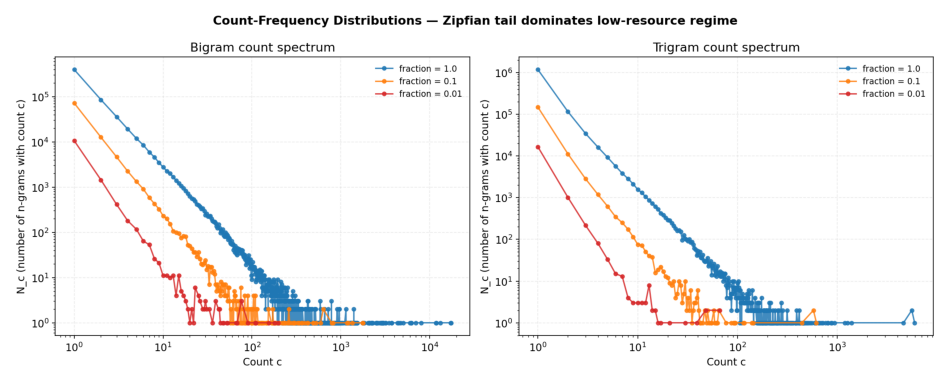


--- decision_matrix.png ---


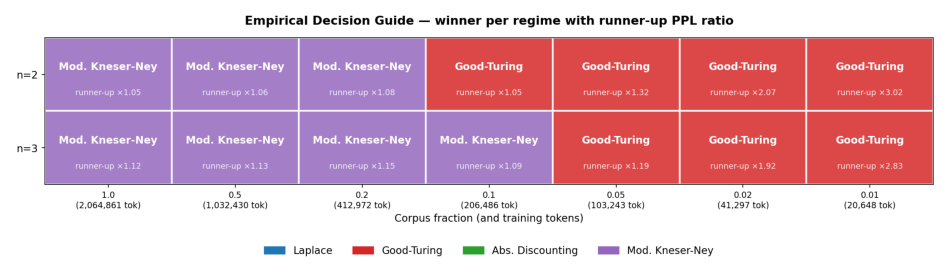


--- kn_discount_evolution.png ---


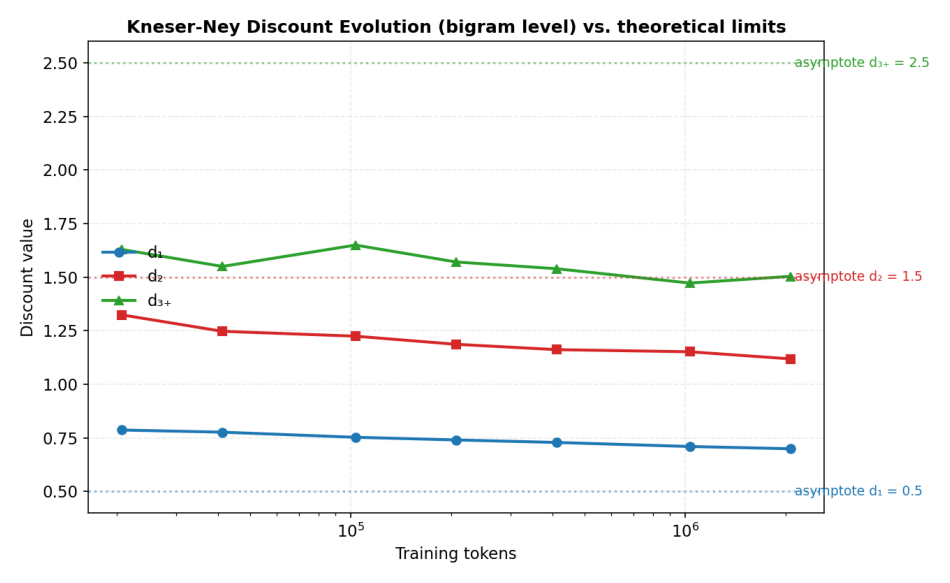


--- oov_and_zero_prob.png ---


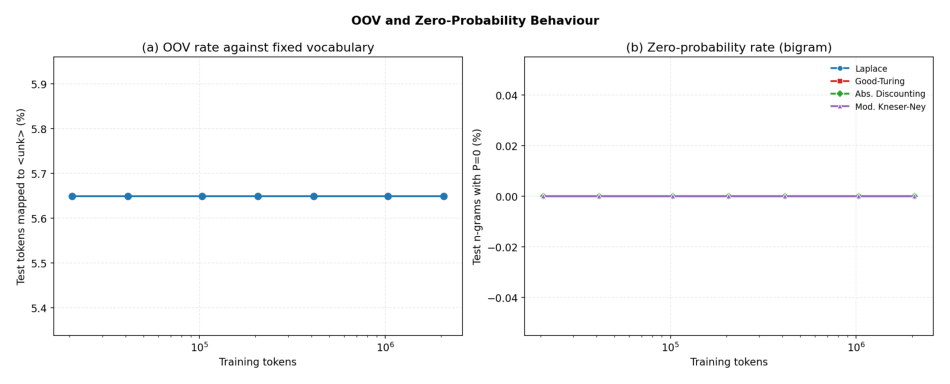


--- perplexity_vs_corpus_size.png ---


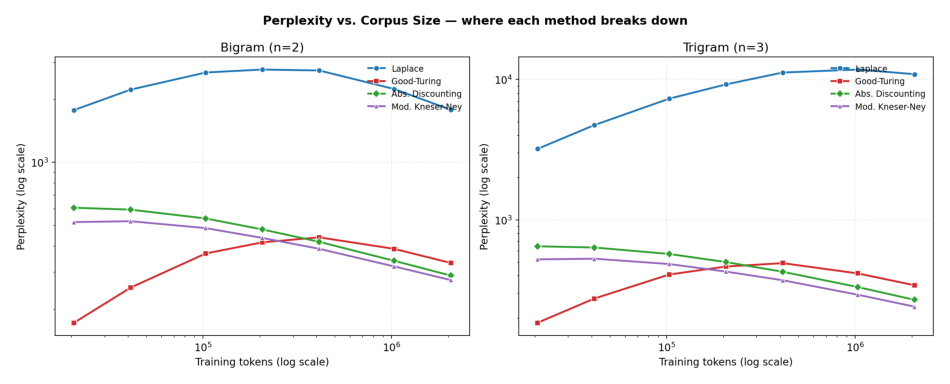


--- rare_word_perplexity.png ---


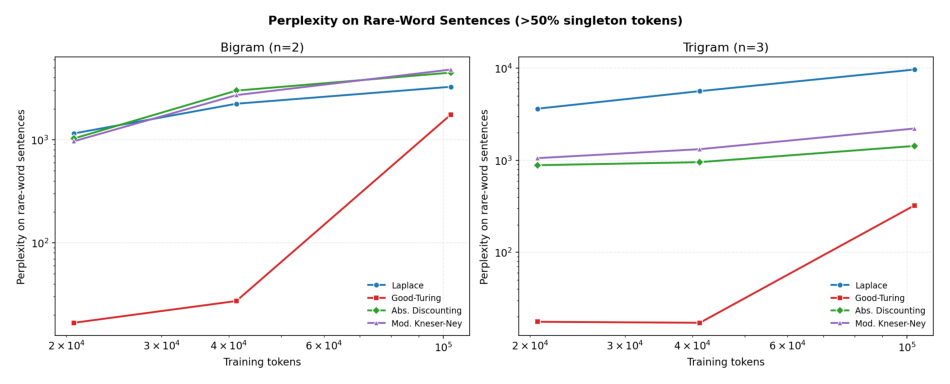


--- relative_perplexity.png ---


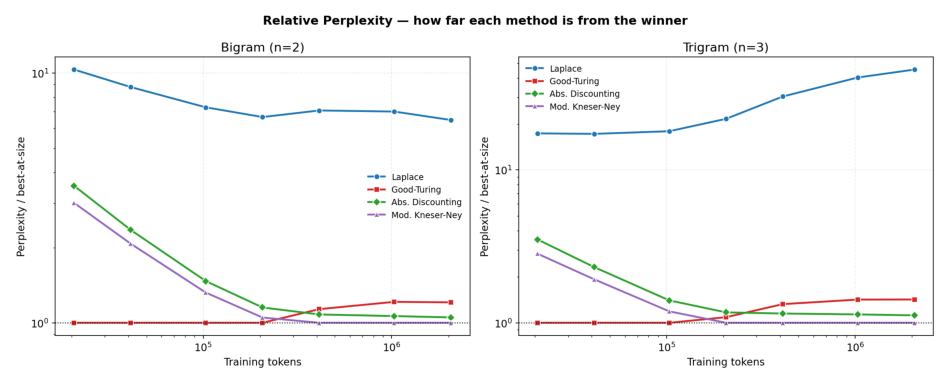


--- sparsity_diagnostics.png ---


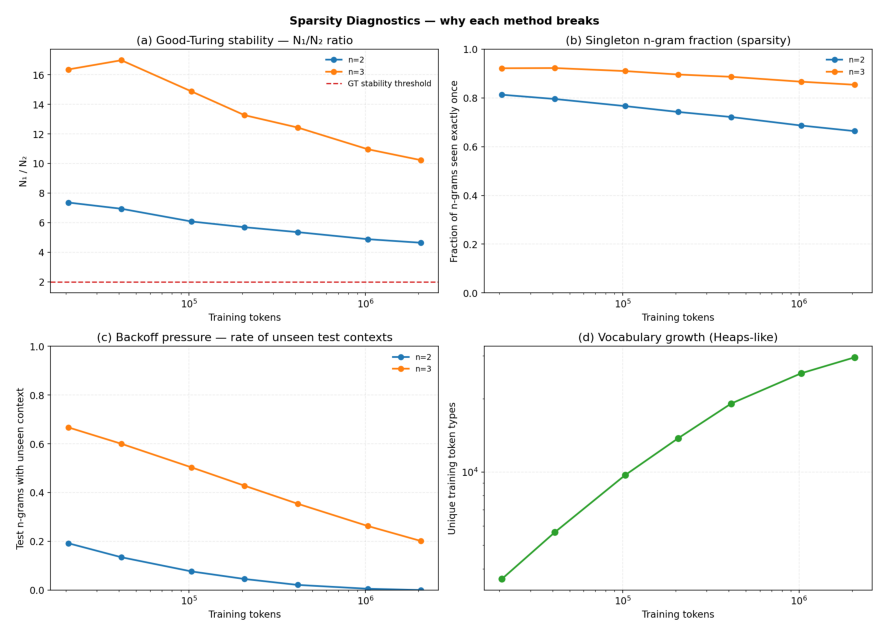

In [7]:
# Display saved plots
plot_files = sorted(PLOTS_DIR.glob("*.png"))
for pf in plot_files:
    print(f"\n--- {pf.name} ---")
    img = plt.imread(pf)
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.imshow(img)
    ax.axis("off")
    plt.show()